# Exercise 5B: Steady-State Groundwater Model - Calibration

Elco Luijendijk | March 2026 | <elco.luijendijk@uib.no>

---

## Exercise Sequence (5A → 5B → 5C)

- **Exercise 5A** (`exercise_5a_model_data.ipynb`): prepare model input datasets (elevation, recharge, geology, surface water).
- **Exercise 5B** (this notebook): build and calibrate the steady-state groundwater model.
- **Exercise 5C**: run flooding and pumping scenarios using the calibrated K field saved here.

## Introduction

In this exercise you build and calibrate a steady-state **depth-integrated** (one-layer) groundwater model for a real Norwegian catchment. “Depth-integrated” means that we represent all groundwater flow in a single map-view layer — a justified simplification for basin-scale water-table mapping.

You will use the geospatial datasets prepared in Exercise 5A (elevation model, recharge, surface water, and geology) and apply calibration methods similar to Exercises 2 and 3, extended to two spatial dimensions.

> **Geology note:** The geology map loaded here already contains both Quaternary deposits (løsmasse) and bedrock (Berggrunn N50) as saved by Exercise 5A. Bedrock units are used directly in Part D, so the spatial variability in both soil and rock types influences the model.

**This notebook (5B) covers model setup and calibration.** Flooding scenarios and strategic pumping are in Exercise 5C, which loads the calibrated K field you save at the end of this notebook.

## Objectives

- Set up a depth-integrated groundwater model from geospatial input datasets.
- Calibrate against multiple target types: observed water-table depths, seepage behaviour, and surface-water connectivity.
- Evaluate model quality with RMSE, R², and a surface-water check for **losing reaches** (places where the modelled water table is below the river or lake bed — physically unrealistic for gaining streams).
- Compare a spatially uniform transmissivity baseline against a geology-guided spatially variable model.

## What to hand in

Hand in a short report (~1 page) documenting your model: describe the catchment, explain your calibration choices, show key maps (model setup, calibration quality, spatial water-table distribution), and briefly interpret the water budget. Include your completed notebook as an appendix.

## Workflow

1. Load and visually inspect model input data.
2. Run a single-parameter (uniform T) baseline model. Optionally calibrate T automatically.
3. Assign hydraulic conductivity K by geology unit. Optionally calibrate per-group K multipliers.
4. Compare both models using RMSE, R², and hydrological target metrics.
5. Save the best calibrated K field for use in Exercise 5C.

*Good luck, and ask for help if you get stuck.*

## Imports

In [1]:

# Run this cell once to install required packages, then comment it out again.
# On Google Colab all lines are needed.  On a local machine most packages
# are likely already installed; uncomment only what is missing.

# !pip install flopy                  # groundwater solver (MODFLOW 6 interface)
# !pip install rasterio               # GeoTIFF reading / rasterization
# !pip install xarray                 # NetCDF / array dataset (save results)
# !pip install cmcrameri              # perceptually-uniform scientific colormaps
# !pip install affine                 # affine transforms (rasterio dependency)


In [ ]:
from pathlib import Path
import importlib
import warnings
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.optimize import minimize_scalar, minimize
import xarray as xr
import cmcrameri.cm as cmc

# -- Detect runtime environment -------------------------------------------------
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# -- Download helper scripts when running on Google Colab ----------------------
if IN_COLAB:
    _raw = ('https://raw.githubusercontent.com/'
            'ElcoLuijendijk/GEOV212_hydrogeology_exercises/main/')
    for _s in ['exercise_5_gw_model_utils.py', 'exercise_5_gw_plot_utils.py']:
        urllib.request.urlretrieve(_raw + _s, _s)
    print('Helper scripts downloaded.')

import exercise_5_gw_model_utils as gwu
import exercise_5_gw_plot_utils as gwp

gwu = importlib.reload(gwu)
gwp = importlib.reload(gwp)

# Keep warning output useful for teaching: suppress only known noisy cases.
warnings.filterwarnings(
    'once',
    message='Using fallback solver because FLOPY/MF6 was unavailable*',
)
warnings.filterwarnings(
    'once',
    message='Could not download mf6 executable*',
)
warnings.filterwarnings(
    'once',
    category=UserWarning,
    message='.*datetime.*',
)
warnings.filterwarnings(
    'once',
    category=UserWarning,
    message='.*tight_layout.*',
)
warnings.filterwarnings(
    'once',
    category=UserWarning,
    message='.*constrained_layout.*',
)

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

print(f"Running on {'Google Colab' if IN_COLAB else 'local machine'}")

Running on local machine


## Model Parameters

All key parameters are collected here.  Read through them before running the
rest of the notebook — understanding each one will help you build and calibrate the model.

In [ ]:
# File paths (Colab or local machine)
if IN_COLAB:
    # scratch space on the Colab VM
    data_dir  = Path('/content/drive/MyDrive/GEOV212_model_input')
    model_dir = Path('/content/tmp_mf6_ex5')
else:
    data_dir  = Path('data/model_input')
    model_dir = Path('tmp_mf6_ex5')
model_dir.mkdir(exist_ok=True)

# Target model cell size (m)
target_cellsize_m = 100.0

# Assumed uniform aquifer thickness; T = K * b (m)
aquifer_thickness_m = 100.0

# Fixed head at open-sea cells (m a.s.l.)
sea_level_m = 0.0

# SW cells (rivers/lakes): fixed streambed/lake-bed clogging layer
# Streambed/lake-bed hydraulic conductivity (m/s)
default_drain_bed_k_m_s       = 2e-6
# Streambed/lake-bed thickness (m)
default_drain_bed_thickness_m = 1.0

# Upland seepage-face cells: conductance scales with local aquifer K
# C = K[r,c] * dx * dy / drain_coupling_depth_m  (Rushton 2003; Beven 1981)
# Effective coupling depth for upland drain cells (m).
# Larger values = more resistive seepage face = less upland drainage.
# Default 10.0 m avoids over-draining with 100 m cells (was 1.0 m = too aggressive).
drain_coupling_depth_m = 10.0

# Slope correction for steep terrain (True = physically more correct)
# Corrects for longer flow paths between cells in plan-view 2D model
apply_slope_correction = True

# Calibration loss weights. Increasing a weight shifts more focus to that criterion.
# Head RMSE at observation borehole points
# R2 at observation points
# Seepage-match fraction at surface-water cells
# Surface-water stage RMSE
# Fraction of SW cells where WT < river/lake bed
cal_weights = {
    'w_rmse'    : 1.0,
    'w_r2'      : 0.75,
    'w_seepage' : 0.5,
    'w_sw_stage': 0.3,
    'w_below_wt': 0.5,
}

# Default figure size and grid display
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True

print(f'Data directory : {data_dir.resolve()}')
print(f'Model directory: {model_dir.resolve()}')


Data directory : /Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/data/model_input
Model directory: /Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/tmp_mf6_ex5


## Map helper functions

Thin wrapper functions that pass the global `grid` dict to the plotting utilities, keeping later call sites short.


In [4]:

# ── Map helper wrappers ────────────────────────────────────────────────────────
# The actual code lives in exercise_5_gw_plot_utils.py.
# These thin wrappers supply the global `grid` dict automatically so that
# existing call sites (e.g. in the input-data figure below) stay unchanged.

def _cbar(im, ax, label='', **kw):
    """Add a colorbar matched to the axes height."""
    return gwp._cbar(im, ax, label, **kw)

def _panel_h():
    """Map panel height (inches) for the current grid aspect ratio."""
    return gwp._panel_h(nrow, ncol)

def add_map_ticks(ax, **kw):
    """Add easting/northing tick labels to a map axes."""
    return gwp.add_map_ticks(ax, grid, **kw)

def add_map_overlays(ax, **kw):
    """Overlay domain boundary and sea mask."""
    return gwp.add_map_overlays(ax, grid, **kw)

print('Map helper wrappers ready (delegating to exercise_5_gw_plot_utils.py).')


Map helper wrappers ready (delegating to exercise_5_gw_plot_utils.py).



---
## Part A: Load and Inspect the Model Input Data

`gwu.load_and_coarsen_inputs` reads five GeoTIFF rasters from `data/model_input/`,
coarsens them to the target cell size, and returns a dictionary of arrays.

**Boundary-condition scheme:**

| Cell type | Boundary |
|---|---|
| Sea cells (`sea == 1`) | Constant head = `sea_level_m` (fixed open-water level, 0 m a.s.l.) |
| River/lake cells (non-sea) | Seepage/drain face with 5× enhanced conductance; drain elevation = DEM − 0.15 m |
| All other active cells | Seepage/drain face; drain elevation = DEM (activates only when WT reaches the surface) |
| Lowest SW cell (only when no sea present) | Constant head = land-surface elevation (hydraulic anchor) |

Drains activate **only** when the modelled head exceeds the drain elevation, so
cells with a deep water table stay dry at the surface.

**Why inspect first?**  A quick visual check can reveal unit errors, misaligned
rasters, or missing values before they cause confusing calibration results.


**Expected output:**
- Grid loads without errors.
- Non-zero counts for active, sea, and surface-water cells.
- Recharge in a plausible range (50–600 mm/yr for a Norwegian catchment).

In [ ]:
# Load and coarsen all raster inputs to the target cell size
grid_data = gwu.load_and_coarsen_inputs(data_dir, target_cellsize_m)

dem       = grid_data['dem']
sw        = grid_data['sw']
sea       = grid_data['sea']
geo       = grid_data['geo']
rch       = grid_data['rch']
active    = grid_data['active']
transform = grid_data['transform']
delr      = grid_data['delr']
delc      = grid_data['delc']
nrow      = grid_data['nrow']
ncol      = grid_data['ncol']
factor    = grid_data['factor']
native_dx = grid_data['native_dx']

# Derived masks
is_sea   = (sea == 1) & active
sw_cells = (sw > 0) & (sw < 3) & active & ~is_sea

# Convert recharge from m/s to mm/yr for display
rch_mm_yr = rch * 365.25 * 24 * 3600 * 1000

print(f'Coarsening factor: {factor}  (native ~{native_dx:.1f} m -> model ~{delr:.1f} m)')
print(f'Grid: {nrow} rows x {ncol} cols')
print(f'Active cells:          {active.sum():,}')
print(f'Sea cells (CHD):       {is_sea.sum():,}')
print(f'SW cells (lake+river): {sw_cells.sum():,}')
rch_active = rch_mm_yr[active]
print(f'Recharge range (active): {rch_active.min():.0f} - {rch_active.max():.0f} mm/yr')
if rch_active.min() == rch_active.max():
    print('  Note: recharge is spatially uniform.')

# Grid info dict passed to all plotting functions
grid = dict(
    dem=dem, active=active, sw_cells=sw_cells, is_sea=is_sea,
    nrow=nrow, ncol=ncol, delr=delr, delc=delc,
    transform=transform, aquifer_thickness_m=aquifer_thickness_m,
    # Extra arrays needed for the water-budget figure inside plot_model_output
    rch=rch, sw_raw=sw, sea_raw=sea,
)


Coarsening factor: 10  (native ~10.0 m → model ~100.0 m)
Grid: 105 rows × 138 cols
Active cells:          7,954
Sea cells (CHD):       3,158
SW cells (lake+river): 168
Recharge range (active): nan – nan mm/yr


## Plot input data overview

Plot all six input arrays (elevation, recharge, geology, surface water, sea mask, active domain) as a single column of maps for a quick spatial sanity check.


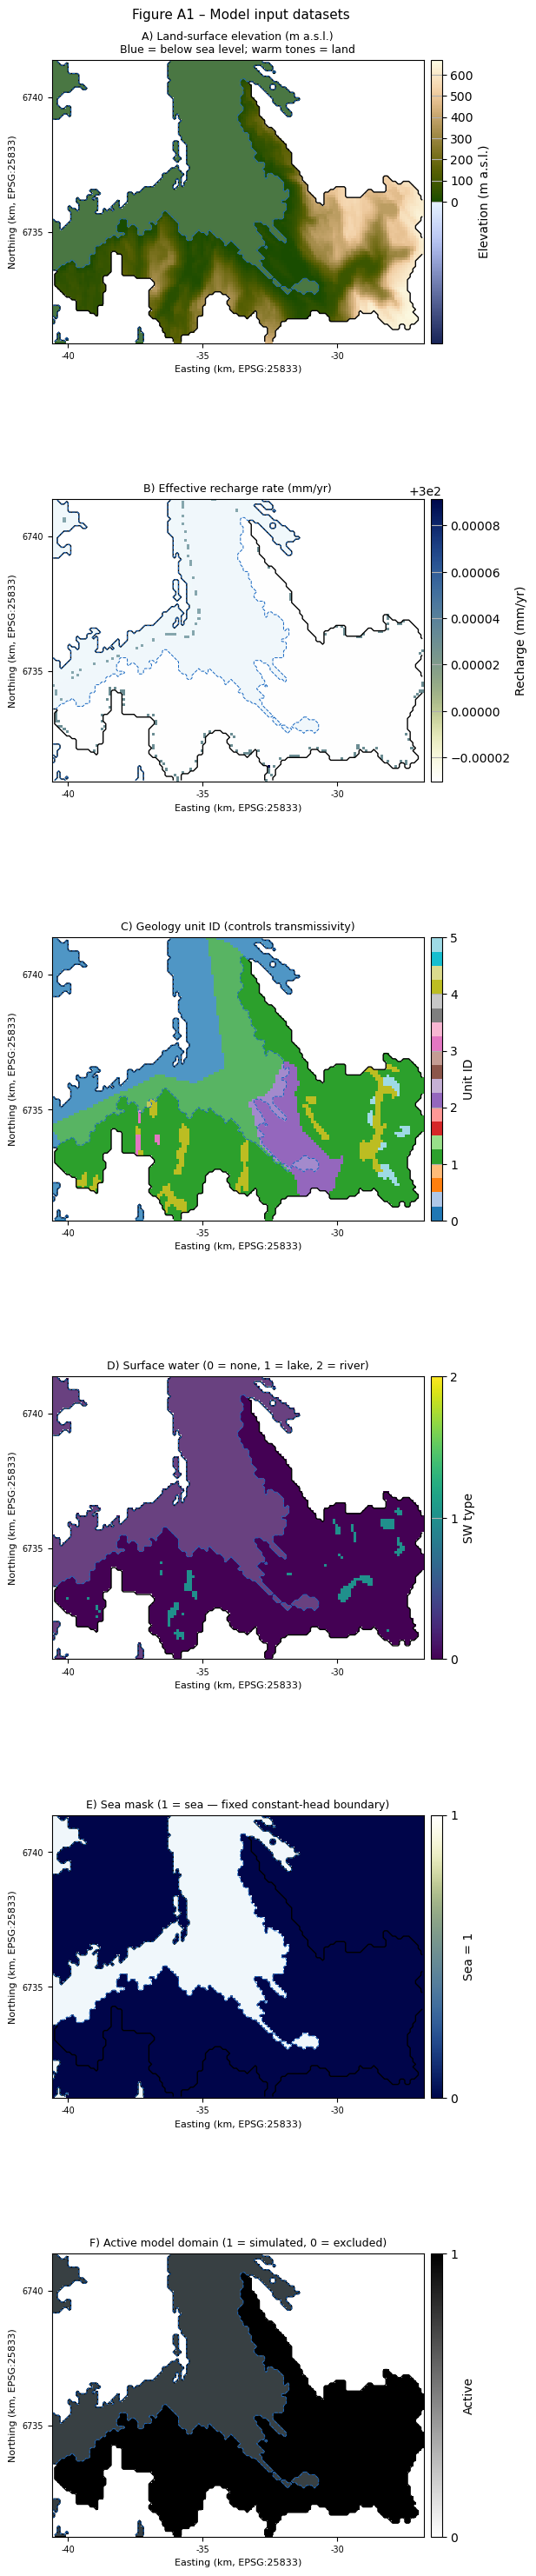

In [ ]:
# Figure A1: Input data overview (6 panels)
ph = _panel_h()
fig, axes = plt.subplots(6, 1, figsize=(7, 6 * ph))
fig.subplots_adjust(left=0.10, right=0.92, top=0.97, bottom=0.01, hspace=0.55)

# Elevation: anchor colormap at 0 m (cmc.oleron: blue below sea level, land tones above)
from matplotlib.colors import TwoSlopeNorm
_dem_min = float(np.nanmin(dem[active]))
_dem_max = float(np.nanmax(dem[active]))
_elev_norm = TwoSlopeNorm(vmin=min(_dem_min, -5.0), vcenter=0.0, vmax=_dem_max)
im0 = axes[0].imshow(np.where(active, dem, np.nan), cmap=cmc.oleron, norm=_elev_norm)
axes[0].set_title('A) Land-surface elevation (m a.s.l.) — blue = below sea level')
_cbar(im0, axes[0], 'Elevation (m a.s.l.)')

im1 = axes[1].imshow(np.where(active, rch_mm_yr, np.nan), cmap=cmc.davos_r)
axes[1].set_title('B) Effective recharge rate (mm/yr)')
_cbar(im1, axes[1], 'Recharge (mm/yr)')

im2 = axes[2].imshow(np.where(active, geo, np.nan), cmap='tab20')
axes[2].set_title('C) Geology unit ID (controls transmissivity)')
_cbar(im2, axes[2], 'Unit ID')

sw_display = np.where(sw_cells, sw.astype(float), 0.0)
im3 = axes[3].imshow(np.where(active, sw_display, np.nan),
                     cmap='viridis', vmin=0, vmax=2)
axes[3].set_title('D) Surface water (0 = none, 1 = lake, 2 = river)')
_cbar(im3, axes[3], 'SW type', ticks=[0, 1, 2])

im4 = axes[4].imshow(sea.astype(float), cmap=cmc.davos, vmin=0, vmax=1)
axes[4].set_title('E) Sea mask (1 = sea — constant-head boundary)')
_cbar(im4, axes[4], 'Sea = 1', ticks=[0, 1])

im5 = axes[5].imshow(active, cmap='gray_r', vmin=0, vmax=1)
axes[5].set_title('F) Active model domain (1 = simulated, 0 = excluded)')
_cbar(im5, axes[5], 'Active', ticks=[0, 1])

for ax in axes:
    add_map_ticks(ax)
    add_map_overlays(ax)

fig.suptitle('Figure A1 – Model input datasets', fontsize=11, y=0.99)
plt.show()


---
## Part A2: Load Watertable Observations

Two observation datasets are used to evaluate model performance:

- **GRANADA** (NGU borehole database): static depth-to-water measurements from drilled wells.
- **NVE timeseries**: groundwater monitoring stations with water-level records.

Both are mapped to the model grid. Where multiple observations fall in the same cell, their heads are averaged.


In [ ]:
import json as _json

# Load GRANADA static well observations (NGU borehole database).
# Filtering: depth_to_water must be present, below drilled depth, and > 0.
_ws_path = data_dir / 'wells_static.geojson'
with open(_ws_path) as _f:
    _ws_gj = _json.load(_f)

_ws_rows = []
for _feat in _ws_gj['features']:
    _p      = _feat['properties']
    _coords = _feat['geometry']['coordinates']
    _dtw     = _p.get('depth_to_water_m')
    _drilled = _p.get('drilled_depth_m') or 9999.0
    if _dtw is None or pd.isna(_dtw):
        continue
    if float(_dtw) >= float(_drilled):
        continue
    if float(_dtw) <= 0.0:
        continue
    _ws_rows.append({
        'station_id':       str(_p['well_id']),
        'source':           'GRANADA_static',
        'x':                float(_coords[0]),
        'y':                float(_coords[1]),
        'water_level_masl': np.nan,
        'depth_to_water_m': float(_dtw),
    })

wells_static_obs = pd.DataFrame(_ws_rows)
print(f'GRANADA static wells passing filters: {len(wells_static_obs)} '
      f'(out of {len(_ws_gj["features"])} total)')

# Load NVE timeseries observations.
# Multiple timesteps per station are averaged to a single representative head.
_wt_path = data_dir / 'wells_timeseries.geojson'
with open(_wt_path) as _f:
    _wt_gj = _json.load(_f)

_wt_rows = []
for _feat in _wt_gj['features']:
    _p      = _feat['properties']
    _coords = _feat['geometry']['coordinates']
    _wl     = _p.get('water_level_masl')
    _dtw    = _p.get('depth_to_water_m')
    if (_wl is None or pd.isna(_wl)) and (_dtw is None or pd.isna(_dtw)):
        continue
    _wt_rows.append({
        'station_id':       str(_p['station_id']),
        'source':           str(_p.get('source', 'NVE_timeseries')),
        'x':                float(_coords[0]),
        'y':                float(_coords[1]),
        'water_level_masl': float(_wl)  if (_wl  is not None and not pd.isna(_wl))  else np.nan,
        'depth_to_water_m': float(_dtw) if (_dtw is not None and not pd.isna(_dtw)) else np.nan,
    })

# Deduplicate: multiple timesteps per station → mean water level
_wt_df = pd.DataFrame(_wt_rows)
if not _wt_df.empty:
    _wt_df = (
        _wt_df
        .groupby('station_id', as_index=False)
        .agg({'source': 'first', 'x': 'first', 'y': 'first',
              'water_level_masl': 'mean', 'depth_to_water_m': 'mean'})
    )
obs = _wt_df
print(f'NVE timeseries stations with water-level data: {len(obs)}')

# Merge both datasets and map to the model grid
obs_combined = pd.concat([obs, wells_static_obs], ignore_index=True)
obs_grid = gwu.map_obs_to_grid(obs_combined, transform, active, dem)
print(f'Total rows mapped to active cells (all sources, raw): {len(obs_grid)}')
print(f'  NVE source rows:     {(obs_grid["source"] != "GRANADA_static").sum()}')
print(f'  GRANADA static rows: {(obs_grid["source"] == "GRANADA_static").sum()}')

# Deduplicate: multiple rows at the same cell → keep mean head
obs_grid = (obs_grid
            .groupby(['r', 'c'], as_index=False)
            .agg({'obs_head_m': 'mean', 'station_id': 'first', 'source': 'first'}))
obs_grid = obs_grid.reset_index(drop=True)
obs_grid.insert(0, 'well_no', range(1, len(obs_grid) + 1))

# Add DEM elevation and depth-to-WT at each observation cell
obs_grid['dem_m']       = [dem[r, c] for r, c in zip(obs_grid['r'], obs_grid['c'])]
obs_grid['obs_depth_m'] = obs_grid['dem_m'] - obs_grid['obs_head_m']

# Drop observations where modelled head is above the land surface (DEM mismatch)
_n_pre = len(obs_grid)
obs_grid = obs_grid[obs_grid['obs_depth_m'] >= 0.0].copy()
obs_grid['well_no'] = range(1, len(obs_grid) + 1)
_n_dropped = _n_pre - len(obs_grid)
if _n_dropped:
    print(f'Note: {_n_dropped} observation(s) dropped — observed head above DEM.')

print('\nObservation well inventory (obs_head_m = water-level m a.s.l.):')
display(obs_grid[['well_no', 'station_id', 'source',
                   'dem_m', 'obs_head_m', 'obs_depth_m']].round(1).to_string(index=False))


---
## Part B: Model Helper Functions

The solver and calibration metric code is in `exercise_5_gw_model_utils.py`. Here we define two convenience functions that you will call throughout the notebook:

- `run_model(hk_arr, recharge_multiplier=1.0, wells=None)` — runs one steady-state simulation with the given K field and returns the modelled water-table head and flow diagnostics. `recharge_multiplier` scales all recharge (> 1 = wetter); `wells` is a list of pumping wells (used in Exercise 5C).
- `evaluate_candidate(hk_arr, obs_grid_df)` — runs the model and then computes all calibration metrics (RMSE, R², seepage match, combined loss). Used by the automated calibration.

**Slope correction for steep terrain** (`apply_slope_correction` in the parameters cell):
A map-view 2D model ignores topographic slope when computing flow between cells. In steep terrain, the actual flow length between two cells is longer than the horizontal cell spacing, making the effective transmissivity lower. The correction factor is:

$$T_\text{eff} = \frac{T}{1 + s^2}, \quad s = \|\nabla z\| \text{ (m/m)}$$

where $s$ is the terrain slope. This factor is computed once from the DEM and applied every time `run_model` is called.

**Boundary conditions in brief:**
- Sea cells → fixed water level at 0 m a.s.l. (constant-head boundary).
- Rivers and lakes → seepage/drain boundary that can exchange water with the aquifer only when the water table is above the streambed.
- Inland cells with no surface water → seepage face (water exits only if head reaches the surface).


**Aquifer type — confined (constant transmissivity):**
Both the MODFLOW 6 solver and the built-in fallback solver treat the aquifer as **confined**, meaning transmissivity T = K × b is held constant and does not change with the water-table depth. This is a deliberate simplification: aquifer thickness b is poorly known for Norwegian catchments and has little influence on the results compared to hydraulic conductivity K, which spans several orders of magnitude. Because both solvers use the same confined assumption, calibrated K values are directly comparable regardless of which solver runs on your machine.

In [7]:

# Pre-compute the slope correction factor from the DEM (done once, reused every run).
_, slope_factor = gwu.apply_slope_correction(
    np.ones_like(dem), dem, delr, delc, active
)
print(f'Slope correction factor – mean: {slope_factor[active].mean():.3f}, '
      f'min: {slope_factor[active].min():.3f}')


def run_model(hk_arr, recharge_multiplier=1.0, wells=None):
    """Run one steady-state simulation with a given K field.

    Parameters
    ----------
    hk_arr : ndarray
        2-D hydraulic conductivity (m/s), same shape as dem.
        The global `apply_slope_correction` flag controls whether
        K is reduced in steep-slope cells before the model run.
    recharge_multiplier : float
        Scale all recharge values.  > 1 = wetter.  Default 1.0.
    wells : list of dict, optional
        Pumping wells; see gwu.simulate for format.  Default None.

    Returns
    -------
    head : ndarray  – hydraulic head (m a.s.l.), NaN outside active domain.
    diagnostics : dict
    """
    if apply_slope_correction:
        hk_use, _ = gwu.apply_slope_correction(hk_arr, dem, delr, delc, active)
    else:
        hk_use = hk_arr

    return gwu.simulate(
        hk_arr=hk_use,
        dem=dem, sw=sw, sea=sea, active=active, rch=rch,
        nrow=nrow, ncol=ncol, delr=delr, delc=delc,
        model_dir=model_dir,
        aquifer_thickness_m=aquifer_thickness_m,
        recharge_multiplier=recharge_multiplier,
        sea_level_m=sea_level_m,
        k_bed=default_drain_bed_k_m_s,
        b_bed=default_drain_bed_thickness_m,
        b_eff=drain_coupling_depth_m,
        wells=wells,
    )


def evaluate_candidate(hk_arr, obs_grid_df):
    """Run the model and compute all calibration metrics for a K field.

    Parameters
    ----------
    hk_arr : ndarray – 2-D hydraulic conductivity (m/s).
    obs_grid_df : pd.DataFrame – observations mapped to grid.

    Returns
    -------
    dict with keys 'head', 'diagnostics', 'eval_df', 'obs_stats',
    'target_stats', 'loss'.
    """
    head, diagnostics = run_model(hk_arr)
    eval_df, obs_stats = gwu.evaluate_vs_obs(head, obs_grid_df)
    target_stats = gwu.seepage_surfacewater_targets(
        head, diagnostics, sw, active)

    loss = gwu.combined_calibration_loss(
        obs_stats, target_stats,
        w_rmse    =cal_weights['w_rmse'],
        w_r2      =cal_weights['w_r2'],
        w_seepage =cal_weights['w_seepage'],
        w_sw_stage=cal_weights['w_sw_stage'],
        w_below_wt=cal_weights['w_below_wt'],
    )
    return {
        'head': head, 'diagnostics': diagnostics,
        'eval_df': eval_df, 'obs_stats': obs_stats,
        'target_stats': target_stats, 'loss': float(loss),
    }


Slope correction factor – mean: 0.925, min: 0.044


## Plotting wrappers

Thin wrappers around the plotting functions in `exercise_5_gw_plot_utils.py`. They capture the global `grid` dict so call sites stay concise.


In [8]:

# ── Plotting wrappers ──────────────────────────────────────────────────────────
# The plotting functions are defined in exercise_5_gw_plot_utils.py.
# These thin wrappers capture the notebook's global `grid` dict so callers
# do not need to pass it explicitly.

def plot_model_output(head, diagnostics, hk_arr, label, show_obs=None):
    """5-panel map: water table, depth-to-WT, Darcy flux, seepage, T."""
    gwp.plot_model_output(head, diagnostics, hk_arr, label, grid,
                          show_obs=show_obs)


def plot_calibration_comparison(head, diagnostics, eval_df,
                                 obs_stats, targets, label):
    """3-panel calibration quality: map (obs coloured by depth), scatter, gaining/losing."""
    gwp.plot_calibration_comparison(head, diagnostics, eval_df,
                                    obs_stats, targets, label, grid)


def plot_cross_sections(head, diagnostics, label, transects=None):
    """
    Plot 2-D hydrogeological cross-sections.

    If *transects* is None, sections are placed automatically perpendicular to
    the water-table contours.  Pass *user_transects* (built in the cell below)
    to use student-defined start/end coordinates instead.
    """
    if transects is None:
        transects = gwu.find_cross_section_transects(
            head, active, nrow, ncol, delr, delc, n_sections=3)
    gwp.plot_cross_sections(
        transects, head, dem, sw, diagnostics['drn_flux'],
        active, delr, delc, aquifer_thickness_m, label)


print('plot_model_output(), plot_calibration_comparison(), '
      'plot_cross_sections() ready.')


plot_model_output(), plot_calibration_comparison(), plot_cross_sections() ready.


---
## Part C: Baseline Model with Uniform Transmissivity

Start by running the model with a single transmissivity value T = K × b applied everywhere. This is the simplest possible model — it has just one free parameter — and gives you a baseline to compare against the geology-based model in Part D.

**What to do:**
1. Set `T_uniform` to a value you think is reasonable for this catchment (see the K table in `#VSC-f9efb612` — multiply by `aquifer_thickness_m` to get T).
2. Run the cell and inspect the output maps and calibration statistics.
3. Optionally set `run_automated_calibration = True` to let the model search for the best T automatically.

### Understanding the calibration loss

The **combined loss** is a single number that summarises how well the model performs. A lower loss is better. It combines five terms:

| Term | What it measures |
|---|---|
| **RMSE** | Average error between modelled and observed water-table depths |
| **R²** | Whether spatial patterns in the water table match observations |
| **Seepage match** | Whether rivers and lakes are gaining (not losing) water |
| **SW stage RMSE** | How closely the modelled water table follows river/lake surface elevations |
| **Losing-reach fraction** | Fraction of river/lake cells where the model predicts the water table is below the streambed |

The weights in `cal_weights` (in the parameters cell) control how much each term counts. You can improve the RMSE at a well and still get a worse combined loss if the model starts to predict that rivers run dry.


**Expected output:**
- Calibrated T in m²/s is printed.
- RMSE, R², and surface-water target metrics are printed.
- Calibration quality maps (observed vs. modelled depth residuals, scatter plot).
- Model output maps: water-table elevation, depth to WT, Darcy flux, seepage, transmissivity.
- Water budget bar chart with recharge, lake/river discharge, and sea flux.

In [ ]:
# ── STUDENT EXERCISE: Choose your starting transmissivity ────────────────────
# T = K * b (hydraulic conductivity × aquifer thickness)
# Start with a single value and run the model. See Part D for geology-based T.
#
# Typical T values for Norwegian catchments (crystalline bedrock + thin sediments):
#   Bedrock only (gneiss, granite): T ~ 1e-5 to 1e-3 m2/s
#   Mixed bedrock + sediment:       T ~ 1e-4 to 1e-2 m2/s
#
# Try changing T_uniform and re-running the cell to see how the water table changes.
T_uniform = 1e-3    # m2/s  <- change this value

# Run the model with the chosen T
hk_uniform = np.where(active, T_uniform / aquifer_thickness_m, 1e-12)
initial_result = evaluate_candidate(hk_uniform, obs_grid)

print(f'Forward run  T = {T_uniform:.1e} m2/s  '
      f'(K = {T_uniform/aquifer_thickness_m:.1e} m/s)')
print(f"  RMSE = {initial_result['obs_stats']['rmse']:.2f} m")
print(f"  R2   = {initial_result['obs_stats']['r2']:.3f}")
print(f"  Loss = {initial_result['loss']:.3f}")

# ── Optional: automated calibration ──────────────────────────────────────────
# Set run_automated_calibration = True to search for the best uniform T
# using scipy. This can take a minute. Leave False to keep the manual T above.
run_automated_calibration = False

if run_automated_calibration:
    cache_uniform = {}

    def objective_uniform(log10_t):
        key = round(float(log10_t), 3)
        if key not in cache_uniform:
            t_val = 10.0 ** log10_t
            hk = np.where(active, t_val / aquifer_thickness_m, 1e-12)
            cache_uniform[key] = evaluate_candidate(hk, obs_grid)['loss']
        return cache_uniform[key]

    res_u = minimize_scalar(
        objective_uniform,
        bounds=(-7.0, -2.0), method='bounded',
        options={'xatol': 0.05, 'maxiter': 25},
    )
    best_t_uniform  = 10.0 ** res_u.x
    best_hk_uniform = np.where(active, best_t_uniform / aquifer_thickness_m, 1e-12)
    uniform_result  = evaluate_candidate(best_hk_uniform, obs_grid)
    print(f'Calibrated T = {best_t_uniform:.3e} m2/s  '
          f'(K = {best_t_uniform/aquifer_thickness_m:.3e} m/s)')
else:
    best_t_uniform  = T_uniform
    best_hk_uniform = hk_uniform
    uniform_result  = initial_result
    print('Using manually set T (set run_automated_calibration = True to optimise).')

head_uniform    = uniform_result['head']
diag_uniform    = uniform_result['diagnostics']
eval_uniform    = uniform_result['eval_df']
stats_uniform   = uniform_result['obs_stats']
targets_uniform = uniform_result['target_stats']

print(f"\nEngine: {diag_uniform['engine']}   anchor: {diag_uniform['anchor']}")
print(f'T = {best_t_uniform:.3e} m2/s')
print()
print('Observation statistics:')
for k, v in stats_uniform.items():
    print(f'  {k:<20s}: {v}')
print()
print('Surface-water / seepage targets:')
for k, v in targets_uniform.items():
    print(f'  {k:<40s}: {v}')
print(f"\nCombined calibration loss: {uniform_result['loss']:.3f}")

activation_uniform = gwu.check_drain_activation(
    head_uniform, diag_uniform, sw, sea, active)
print('\nDrain activation summary:')
display(activation_uniform)


GRANADA static wells passing filters: 16 (out of 64 total)
NVE timeseries stations with water-level data: 16
Total rows mapped to active cells (all sources, raw): 32
  NVE source rows: 16
  GRANADA static rows: 16
Note: 2 observation(s) dropped — observed head above DEM (DEM resolution mismatch or artesian conditions).

Observation well inventory (obs_head_m = water-level m a.s.l.):


' well_no station_id         source     dem_m  obs_head_m  obs_depth_m\n       1      21330 GRANADA_static 18.600000        17.1          1.5\n       2      55886 GRANADA_static 31.700001        24.7          7.0\n       3     119296 GRANADA_static  3.500000         2.5          1.0\n       4      10004 GRANADA_static 39.000000       -31.0         70.0\n       5     141713 GRANADA_static 48.099998        47.5          0.6\n       6     141715 GRANADA_static 63.099998        61.6          1.5\n       7     141714 GRANADA_static 57.599998        54.6          3.0\n       8     141718 GRANADA_static 43.299999        39.5          3.8\n       9     141717 GRANADA_static 52.099998        51.6          0.5\n      10     129754 GRANADA_static  2.000000         0.0          2.0\n      11     129758 GRANADA_static  1.800000        -0.4          2.2\n      12     129762 GRANADA_static  2.900000         1.2          1.7\n      13     129763 GRANADA_static  2.400000         1.1          1.3'

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model gwf_ex5...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package drn_0...
    writing package chd_0...
    writing package oc...


/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: MODFLOW 6 run failed: 
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")


Pre-calibration run  T = 1.0e-04 m²/s  (K = 1.0e-06 m/s)
  RMSE = 15.44 m
  R²   = 0.675
  Loss = 4.270
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model gwf_ex5...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package drn_0...
    writing package chd_0...
    writing package oc...


...

/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: MODFLOW 6 run failed: 
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model gwf_ex5...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package drn_0...
    writing package chd_0...
    writing package oc...


/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: MODFLOW 6 run failed: 
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")


Solver: iterative-fallback   anchor: sea cells as fixed head (0 m)
Best T = 6.294e-05 m²/s  (K = 6.294e-07 m/s)

Observation statistics:
  n                   : 13
  rmse                : 14.913643274256211
  mae                 : 7.452994260943472
  bias                : 0.7900492501313372
  r2                  : 0.6964193555223379

Surface-water / seepage targets:
  n_surface_water_cells                   : 168
  seepage_match_fraction                  : 0.041666666666666664
  surfacewater_stage_rmse_m               : 46.43048841206752
  seepage_surfacewater_jaccard            : 0.021212121212121213
  n_sw_below_wt                           : 161
  below_wt_fraction                       : 0.9583333333333334

Combined calibration loss: 4.177

Drain activation summary:


,feature,n_cells,n_drn_active,active_fraction
0,river,0,0,NaN
1,lake,168,7,0.041667
2,sea,3158,0,1.000000


## Plot calibration quality – uniform T

Plot the observed vs modelled water-table depths, and show which surface-water cells are losing (water table below stream/lake bed).


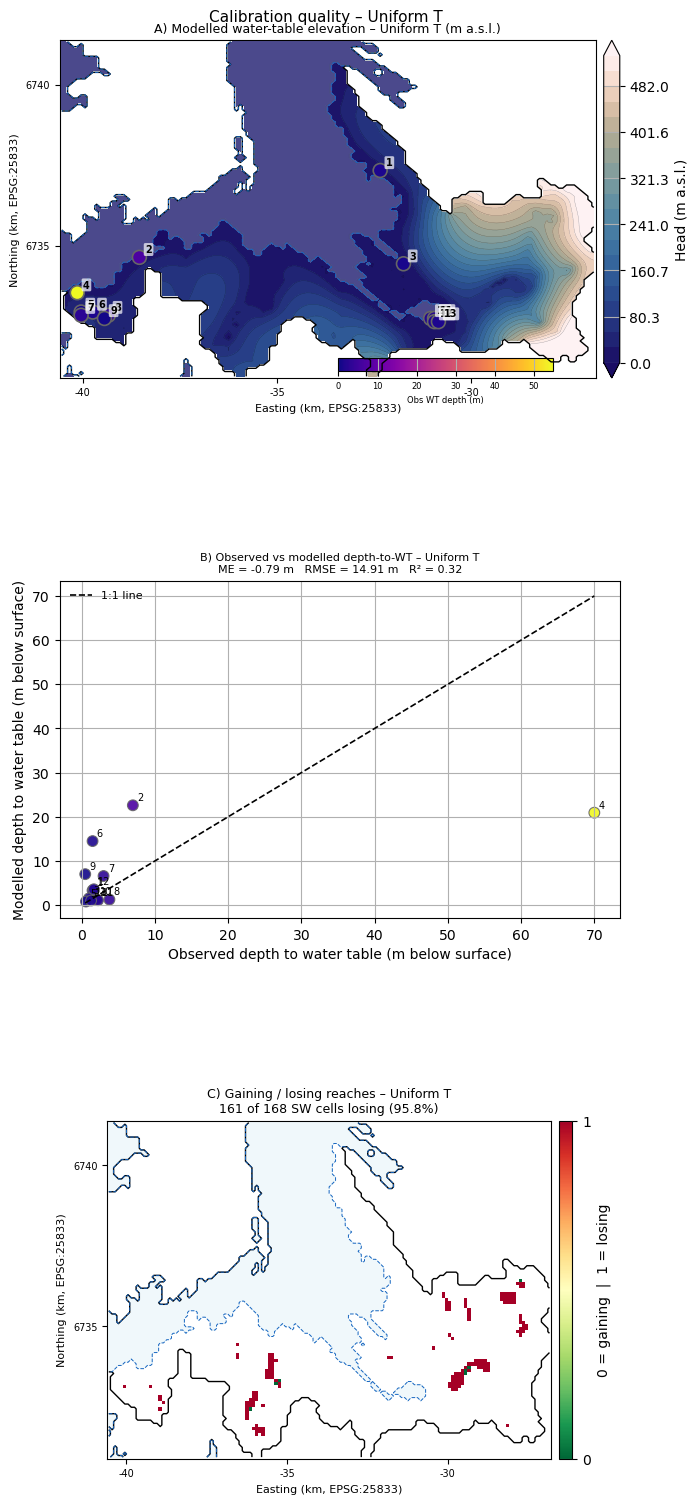


Modelled vs observed depth-to-water-table – Uniform T:


,Well #,Station ID,Obs. depth-to-WT (m),Model depth-to-WT (m),Residual (m)
0,1,21330,1.50,3.35,1.85
1,2,55886,7.00,22.61,15.61
2,3,119296,1.00,1.54,0.54
4,4,10004,70.00,20.94,-49.06
6,5,141713,0.60,0.83,0.23
7,6,141715,1.50,14.51,13.01
8,7,141714,3.00,6.61,3.61
9,8,141718,3.80,1.27,-2.53
10,9,141717,0.50,7.03,6.53
11,10,129754,2.00,1.37,-0.63


In [10]:

# Calibration quality: map, scatter, residuals, gaining/losing reaches
plot_calibration_comparison(
    head_uniform, diag_uniform, eval_uniform,
    stats_uniform, targets_uniform, 'Uniform T'
)

# Modelled vs observed depth-to-WT table (numbered wells)
if not eval_uniform.empty:
    print('\nModelled vs observed depth-to-water-table – Uniform T:')
    tbl = eval_uniform.copy()
    tbl['model_depth_m'] = tbl['dem_m'] - tbl['model_head_m']
    tbl['depth_resid_m'] = tbl['model_depth_m'] - tbl['obs_depth_m']
    tbl_disp = tbl[['well_no', 'station_id',
                     'obs_depth_m', 'model_depth_m', 'depth_resid_m']].round(2)
    tbl_disp.columns = ['Well #', 'Station ID',
                         'Obs. depth-to-WT (m)', 'Model depth-to-WT (m)', 'Residual (m)']
    display(tbl_disp)


## Model output maps – uniform T

Six-panel spatial overview: water-table elevation, depth to WT, Darcy flux with flow arrows, seepage flux, flux to surface water, and transmissivity.


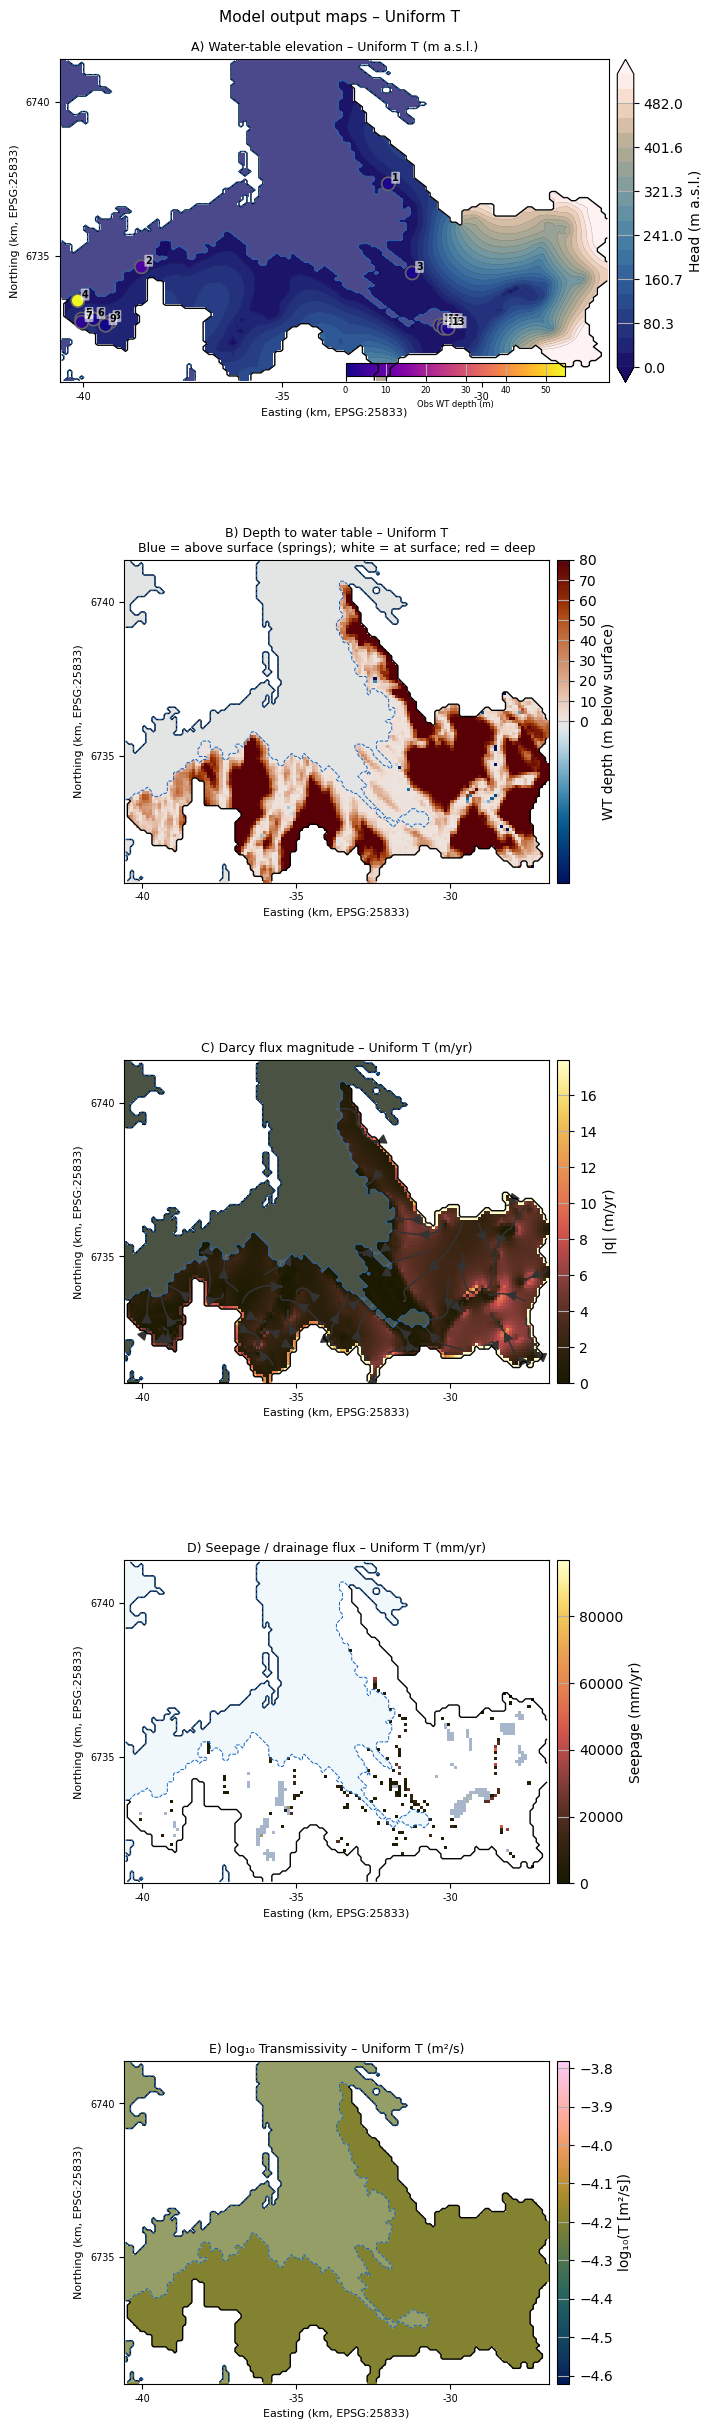

In [11]:

# Full model output maps for the uniform-T calibration
plot_model_output(
    head_uniform, diag_uniform, best_hk_uniform, 'Uniform T',
    show_obs=eval_uniform if not eval_uniform.empty else None
)
# Also keep the losing-reach diagnostic arrays for Part D comparison
drn_elev_u = diag_uniform['drn_elev']
below_wt_u = sw_cells & np.isfinite(head_uniform) & (head_uniform < drn_elev_u)


## Define cross-section transects

Enter start and end coordinates for each geological cross-section. The code builds transect dicts that are passed to the cross-section plotting function.

**Tips for choosing good transects:**
- Align sections roughly along the groundwater flow direction (upland → coast) to show the full head gradient.
- Include a valley transect to see how the water table follows topography and where it reaches the surface (seepage zones).
- A coast-perpendicular section shows sea–land gradients and the freshwater–saltwater interface zone.

**What to look for in the cross-section plots:**
- **Depth to WT**: shallower in valleys and near the coast, deeper in uplands.
- **Seepage zones** (WT at or above DEM): should coincide with rivers and lakes, not appear on dry hillslopes.
- **Slope of the water table**: steeper slopes = larger hydraulic gradient = faster groundwater flow.
- **Differences between models**: does geology K change the WT depth systematically in certain lithologies?

In [ ]:
# ── Student-defined cross-section lines ──────────────────────────────────────────────
# Enter start and end coordinates (easting, northing in metres, EPSG:25833) for
# each cross-section you want to plot.
#
# How to pick good coordinates:
#   • Read easting and northing (in metres) off the map tick labels above.
#     Tick labels show kilometres; multiply by 1000 to get metres.
#   • Orient sections along the flow direction (high head → low head) to
#     show the saturated zone and discharge zone clearly.
#   • A coast-perpendicular section captures sea–land WT gradients.
#   • A section along a valley floor shows shallow WT and seepage zones.
#
# The defaults below span the full model domain.  The 1st section (A–B) runs
# W–E through the N–S midpoint; the 2nd section (C–D) runs N–S through the
# E–W midpoint.  Adjust the coordinates to focus on features of interest.

# Full model-domain extent from the Affine transform.
_x_min = transform.c
_x_max = transform.c + ncol * delc
_y_max = transform.f
_y_min = transform.f - nrow * delr
_x_mid = (_x_min + _x_max) / 2.0
_y_mid = (_y_min + _y_max) / 2.0

user_xsection_endpoints = [
    {'label': 'Section 1 (A-B, W-E)',
     'start_xy': (_x_min, _y_mid),
     'end_xy':   (_x_max, _y_mid)},
    {'label': 'Section 2 (C-D, N-S)',
     'start_xy': (_x_mid, _y_max),
     'end_xy':   (_x_mid, _y_min)},
    # Add or remove entries as needed:
    # {'label': 'Section 3', 'start_xy': (x0, y0), 'end_xy': (x1, y1)},
]

# Build transect dicts from the endpoint coordinates.
user_transects = []
for ep in user_xsection_endpoints:
    try:
        tr = gwu.make_transect_from_endpoints(
            ep['start_xy'], ep['end_xy'],
            transform, delr, delc, active, label=ep['label'])
        user_transects.append(tr)
        km = tr['dist_m'][-1] / 1000.0
        print(f"  {tr['label']}: {len(tr['rows'])} active cells, "
              f"length {km:.1f} km")
    except ValueError as exc:
        print(f'  Warning [{ep["label"]}]: {exc}')

if not user_transects:
    print('No valid transects — check coordinates above.')
    print('Automatic section placement will be used as fallback.')

  Section 1 (A–B, W–E): 116 active cells, length 12.8 km
  Section 2 (C–D, N–S): 94 active cells, length 9.3 km


## Plot cross-sections – uniform T

Cross-sections showing topography, modelled water table, and seepage zones for the uniform T model.

**What to look for:**
- Does the water table follow topography broadly, or is it very flat?
- Where does the WT reach or exceed the land surface? These should correspond to river/lake locations.
- How deep is the WT in upland areas? A very deep WT may indicate K is too high (water drains too fast).

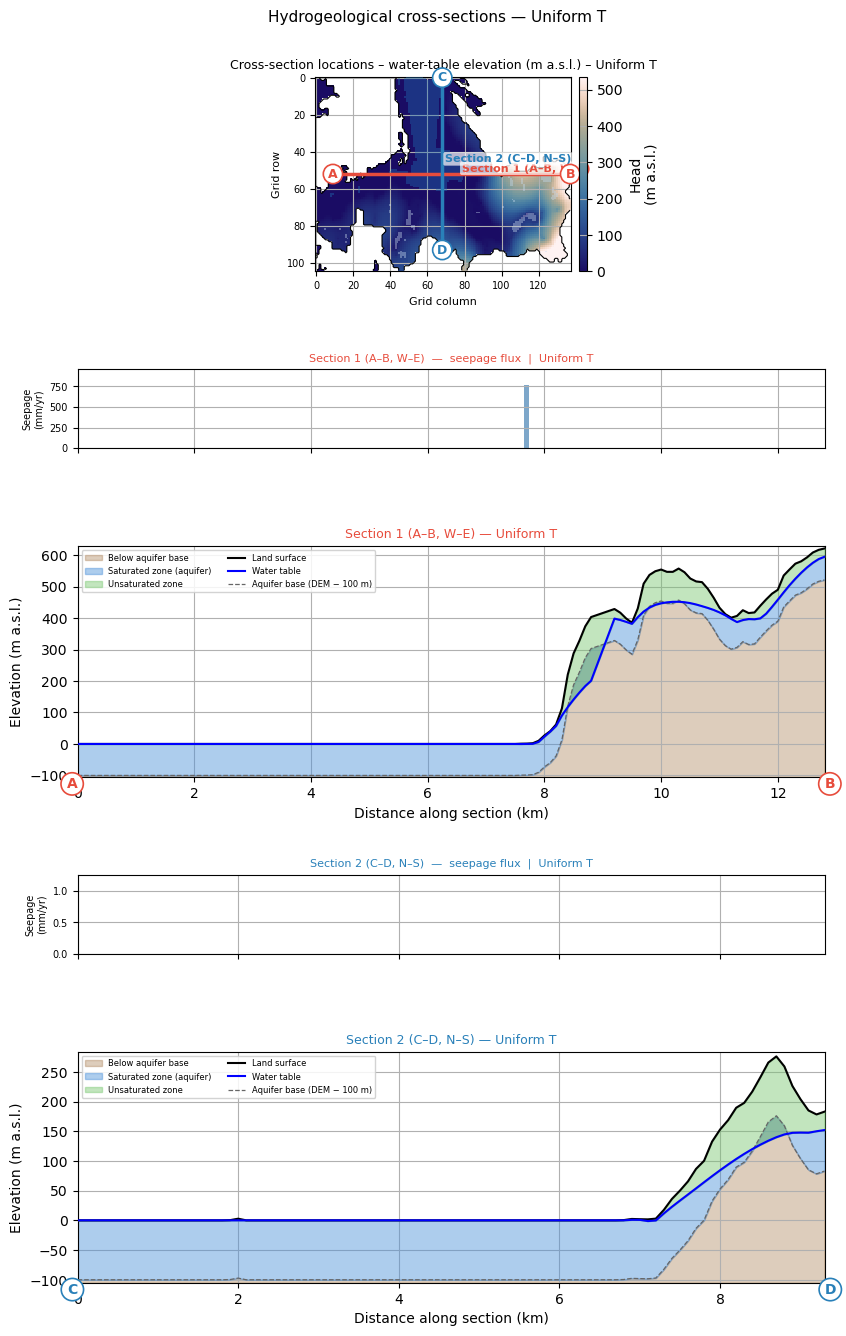

In [13]:

# Cross-sections along student-defined lines – Uniform T
plot_cross_sections(head_uniform, diag_uniform, 'Uniform T',
                    transects=user_transects if user_transects else None)


---
## Part D: Geology-Based Model with Spatially Variable K

Hydraulic conductivity (K) varies by several orders of magnitude between rock and soil types (see the Gleeson et al. table below). Assuming a single uniform T everywhere ignores this variability. In Part D you assign different K values to different geology units and check whether this improves the model.

**Three-stage workflow:**

1. **Stage D1 — Assign K by geology unit.** The code reads the geology legend (including both Quaternary deposits and bedrock from Exercise 5A) and assigns a default K to each unit based on its type. You can inspect the table and override values for specific units using `custom_k_by_unit`.

2. **Stage D2 — Group units into calibration zones.** To keep calibration tractable, you group related units together (e.g. all Quaternary deposits in one group, all bedrock in another). One log-scale multiplier is calibrated per group. For example, a multiplier of +1 means K is multiplied by 10¹ = ×10; a multiplier of −1 means K is divided by 10.

3. **Stage D3 — Run the model and optionally calibrate.** A forward run is made first so you can see how the geology K performs before calibration. Setting `run_geo_calibration = True` then searches for the best group multipliers automatically.



### Stage D1: Geology units in the active model domain


In [ ]:

# Read the geology legend and list all units present in the active model domain.
# The legend was created in Exercise 5A and includes both:
#   - Quaternary deposits (løsmasse, source = 'losmasse')
#   - Bedrock units (source = 'berggrunn_n50')
legend = pd.read_csv(data_dir / 'geology_legend.csv')
geo_unit_table = gwu.list_geology_units_in_domain(geo, legend, active)

pd.set_option('display.max_colwidth', 65)
pd.set_option('display.max_rows', 50)
print(f'{len(geo_unit_table)} geology units found in active model domain:')
print('  source=losmasse -> Quaternary deposits (K from gw_potential text)')
print('  source=berggrunn_n50 -> Bedrock units (K from lithology name)')
print()
display(geo_unit_table[['id', 'n_cells', 'source', 'deposit_type', 'gw_potential', 'k_default_m_s']])


6 geology units found in active model domain:



,id,n_cells,deposit_type,gw_potential,k_default_m_s
0,0,8015,(not in legend),,3.000000e-06
1,1,5195,Bart fjell,Antatt ikke grunnvannspotensial i løsmassene,2.000000e-05
2,2,744,Fyllmasse (antropogent materiale),Antatt ikke grunnvannspotensial i løsmassene,8.000000e-07
3,4,421,"Morenemateriale, usammenhengende eller tynt dekke over berggr...",Antatt ikke grunnvannspotensial i løsmassene,2.000000e-05
4,5,89,"Skredmateriale, sammenhengende dekke",Antatt ikke grunnvannspotensial i løsmassene,2.000000e-05
5,3,26,"Morenemateriale, sammenhengende dekke, stedvis med stor mekti...",Antatt begrenset grunnvannspotensial,2.000000e-05


#### Stage D1: Assign K values per geology unit (optional)

Inspect the unit table above. You can override the default K value for any unit by adding its **ID** and your chosen **K (m/s)** to the `custom_k_by_unit` dictionary. Leave it empty to use the legend-derived defaults.

**How default K values are assigned**

For **Quaternary deposits (løsmasse)**, the default K is inferred from the Norwegian groundwater potential text in the legend (e.g. "betydelig" = high potential → K ~ 8×10⁻⁵ m/s; "lite" = low potential → K ~ 5×10⁻⁶ m/s). Units without potential text fall back to 3×10⁻⁶ m/s.

For **bedrock units (source = berggrunn\_n50)**, the default K is assigned from the lithology name (e.g. "granitt", "gneis" → 5×10⁻⁸ m/s; "kalkstein" → 2×10⁻⁷ m/s; "sandstein" → 5×10⁻⁷ m/s). These represent bulk fractured-rock conductivity following Gleeson et al. (2011).

**Hydraulic conductivity ranges based on Gleeson et al. (2011), Table 1**
[(doi: 10.1029/2010GL045565)](https://doi.org/10.1029/2010GL045565):

Gleeson et al. compiled global K estimates spanning roughly **7 orders of magnitude** — from crystalline bedrock (~10⁻¹⁰ m/s) to unconsolidated coarse sand and gravel (~10⁻³ m/s).

| Material | Typical K (m/s) |
|---|---|
| Gravel, coarse sand | 10⁻⁴ – 10⁻² |
| Medium to fine sand | 10⁻⁶ – 10⁻⁴ |
| Sandy or silty till (Quaternary) | 10⁻⁷ – 10⁻⁵ |
| Compact till, silt | 10⁻⁹ – 10⁻⁷ |
| Fractured granite/gneiss (bedrock) | 10⁻⁸ – 10⁻⁶ |
| Unfractured crystalline rock | 10⁻¹² – 10⁻⁹ |

**Note on transmissivity:**
Transmissivity T = K × b, where b is the saturated aquifer thickness. Since b is poorly constrained in this model (we use a uniform value of `aquifer_thickness_m`), the actual T is uncertain even if K is correct. The calibration in Stages D2–D3 compensates for this by scaling K group-wise.


Use `custom_k_by_unit` to override K (m/s) for specific unit IDs. Leave the dictionary empty to use the legend-derived defaults. Run the cell even if you leave it empty.


In [ ]:
# ── STUDENT EXERCISE: Assign K values per geology unit ───────────────────────
# The table above lists each geology unit and a default K (m/s) derived from
# Norwegian keywords in the legend.
#
# You can override K for any unit by adding its ID and your chosen K to the
# dictionary below. Leave the dictionary empty to use the defaults.
#
# Example: custom_k_by_unit = {3: 2e-5, 7: 8e-6}
custom_k_by_unit = {}

# Build the geology K map: start from legend defaults, apply any overrides
id_to_k = dict(zip(geo_unit_table['id'].astype(int),
                   geo_unit_table['k_default_m_s'].astype(float)))
for _uid, _k in custom_k_by_unit.items():
    _uid = int(_uid)
    _k = float(_k)
    if _uid not in id_to_k:
        raise ValueError(f'Unit ID {_uid} not present in active model domain.')
    if _k <= 0:
        raise ValueError(f'K for unit {_uid} must be > 0 m/s.')
    id_to_k[_uid] = _k

# Assign K to every active cell based on its geology unit ID
hk_geo_units = np.full_like(dem, 1e-12, dtype=float)
for _uid, _k in id_to_k.items():
    hk_geo_units[(geo == _uid) & active] = _k

# hk_geo_base is the starting K field for Stage D3 calibration
hk_geo_base = np.where(active, hk_geo_units, 1e-12)

print(f'Geology K field summary (active cells):')
print(f'  min K = {hk_geo_base[active].min():.2e} m/s')
print(f'  max K = {hk_geo_base[active].max():.2e} m/s')
print(f'  mean K = {hk_geo_base[active].mean():.2e} m/s')
if custom_k_by_unit:
    print('Applied custom K overrides (unit_id -> K m/s):')
    for _uid in sorted(custom_k_by_unit):
        print(f'  {_uid}: {custom_k_by_unit[_uid]:.2e}')
else:
    print('No custom K overrides; using legend-derived defaults.')


Geology calibration base K (uniform, from Part C): 6.29e-07 m/s
Per-group multipliers in Stage D3 will be applied on top of this value.


## Map of assigned K values

Inspect the geology K field before calibration. A plausible map should show higher K in valley bottoms and Quaternary deposits, lower K in upland bedrock areas.


In [ ]:
# Map of assigned K values (log10 scale) – check that the geology-based K field
# looks spatially reasonable before proceeding to calibration.
ph = _panel_h()
fig, ax = plt.subplots(1, 1, figsize=(7, ph))
fig.subplots_adjust(left=0.10, right=0.92, top=0.92, bottom=0.10)

_log_k = np.where(active, np.log10(np.maximum(hk_geo_base, 1e-12)), np.nan)
im_k = ax.imshow(_log_k, cmap='RdYlBu')
ax.set_title('Assigned log10(K) from geology legend (m/s)')
_cbar(im_k, ax, 'log10(K [m/s])')
add_map_ticks(ax)
add_map_overlays(ax)
plt.show()


### Stage D2: Define calibration groups

Group the geology unit IDs into categories. During automated calibration (Stage D3), each group gets one **log-scale K multiplier** — all units in the group are scaled by the same factor. The calibration finds the multiplier that minimises the combined loss.

> **Why log-scale?** Because K spans many orders of magnitude, it makes more sense to multiply K by a factor (×10, ×0.1) than to add or subtract a fixed number. A log-scale multiplier of +1 means ×10; −1 means ×0.1; 0 means no change.

You need at least two groups. Replace the placeholder IDs with the correct ones for your catchment — use the unit ID table from Stage D1.

| Group | Typical material | Typical K (m/s) |
|---|---|---|
| Quaternary deposits | Glacial till, moraine, alluvium, peat | 10⁻⁶ – 10⁻⁴ |
| Bedrock | Gneiss, granite, schist | 10⁻⁹ – 10⁻⁷ |


In [ ]:
# ── STUDENT EXERCISE: Define your geological calibration groups ───────────────
# Look at the unit ID table printed above (Stage D1).
# Group the IDs into 2–4 categories. Each group gets one K multiplier during
# calibration — units in the same group are scaled together.
#
# The default below auto-populates two groups from the Stage D1 table:
#   'quaternary'  → all units with source == 'losmasse'
#   'bedrock'     → all units with source == 'berggrunn_n50'
# This is a sensible starting point. You can split groups further
# (e.g. separate coarse vs. fine Quaternary) by adding more entries.
#
# To override: replace the auto-filled lists with explicit unit IDs, e.g.
#   geo_groups = {
#       'quaternary': [3, 7, 12],
#       'bedrock':    [1, 5, 9, 14],
#   }

# Auto-populate groups from the Stage D1 legend table
_q_ids  = sorted(geo_unit_table.loc[
    geo_unit_table['source'] == 'losmasse', 'id'].astype(int).tolist())
_b_ids  = sorted(geo_unit_table.loc[
    geo_unit_table['source'] == 'berggrunn_n50', 'id'].astype(int).tolist())
# Units not matched to either source (e.g. unclassified bedrock, unit 0)
_all_ids    = set(int(i) for i in geo_unit_table['id'].astype(int))
_known_ids  = set(_q_ids) | set(_b_ids)
_other_ids  = sorted(_all_ids - _known_ids)

geo_groups = {
    'quaternary': _q_ids,    # Quaternary deposits (glacial till, moraine, alluvium)
    'bedrock':    _b_ids,    # Classified bedrock (gneiss, granite, schist, …)
}
if _other_ids:
    geo_groups['other'] = _other_ids  # Unclassified units (treated as bedrock)


# If not all active unit IDs are listed above, the model will raise an error
# (to prevent silent misclassification). Set True only if you want unassigned
# units to go into the last group as a fallback.
allow_unassigned_fallback = False

# ── Validation ────────────────────────────────────────────────────────────────
active_unit_ids   = set(np.unique(geo[active]).astype(int))
assigned_unit_ids = set(int(uid) for ids in geo_groups.values() for uid in ids)
missing_unit_ids  = sorted(active_unit_ids - assigned_unit_ids)

if missing_unit_ids and not allow_unassigned_fallback:
    raise ValueError(
        'Some active geology unit IDs are not assigned to any group: '
        f'{missing_unit_ids}. Add them to geo_groups or set '
        'allow_unassigned_fallback = True.'
    )

if missing_unit_ids and allow_unassigned_fallback:
    print('Note: the following unassigned units will be put in the last group:')
    print(f'  {missing_unit_ids}')

# Build a group-index array: each active cell gets a number 0..n_groups-1
group_labels, group_names = gwu.make_k_by_geo_groups(
    geo, active, geo_groups, allow_fallback=allow_unassigned_fallback,
)

print('Calibration group summary:')
for i, name in enumerate(group_names):
    n_cells = int((group_labels == i).sum())
    ids_in_group = geo_groups.get(name, [])
    print(f'  Group {i + 1}: "{name}" — {n_cells:,} active cells  '
          f'(unit IDs: {ids_in_group})')


Calibration group summary:
  Group 1: "quaternary" — 26 active cells
  Group 2: "bedrock" — 7,928 active cells


## Run geology model and optional group calibration

Run a forward model with the geology K base field. Optionally run Nelder-Mead optimisation to find the best per-group K multipliers.


**Expected output (Stage D3):**
- Geology K field summary printed: min/max/mean K (m/s).
- Forward-run RMSE, R², and combined loss printed. Compare with the uniform T result from Part C.
- If `run_geo_calibration = True`: optimised per-group multipliers printed, followed by calibrated RMSE/R²/loss.
- Calibration quality maps, model output maps, and water budget shown (same figures as Part C, now for the geology model).

In [ ]:
# ── Run a forward model with the geology K base field ────────────────────────
# Before calibration, check how the geology K map performs on its own.
# Compare the loss with the uniform T result from Part C.
geo_base_result = evaluate_candidate(hk_geo_base, obs_grid)
print('Geology K — forward run (no calibration):')
print(f"  RMSE = {geo_base_result['obs_stats']['rmse']:.2f} m")
print(f"  R²   = {geo_base_result['obs_stats']['r2']:.3f}")
print(f"  Loss = {geo_base_result['loss']:.3f}")
print()

# ── Optional: automated group calibration ────────────────────────────────────
# Set run_geo_calibration = True to search for the best per-group K multipliers
# using Nelder-Mead optimisation (simplex method). Takes a few minutes.
# Each group's K is multiplied by 10^m, where m is the optimised exponent.
run_geo_calibration = False

# Limits to keep the calibration physically sensible:
#   _MAX_GROUP_MULT  : maximum log10 multiplier per group (±3 means K can vary by ×1000)
#   _MAX_K_LOG_RANGE : maximum allowed log10 spread across the whole K field (4 = 4 orders of magnitude)
_MAX_GROUP_MULT  = 3.0
_MAX_K_LOG_RANGE = 4.0


def build_hk_from_groups(log10_mults):
    """
    Apply per-group log10 multipliers to the base geology K field.

    Each group's K is scaled by 10^m (m is clipped to ±_MAX_GROUP_MULT).
    An overall K-contrast limit is then applied so no single cell is
    more than 10^_MAX_K_LOG_RANGE times higher/lower than the median.
    """
    mults = np.clip(np.asarray(log10_mults, dtype=float),
                    -_MAX_GROUP_MULT, _MAX_GROUP_MULT)
    hk = hk_geo_base.copy()
    for i in range(len(group_names)):
        hk[group_labels == i] *= 10.0 ** mults[i]
    hk = gwu.limit_k_contrast(hk, active, max_log10_range=_MAX_K_LOG_RANGE)
    return np.where(active, hk, 1e-12)


if run_geo_calibration:
    cache_geo = {}

    def objective_geo(log10_mults):
        key = tuple(np.round(np.asarray(log10_mults, dtype=float), 3))
        if key not in cache_geo:
            hk = build_hk_from_groups(log10_mults)
            cache_geo[key] = evaluate_candidate(hk, obs_grid)['loss']
        return cache_geo[key]

    res_g = minimize(
        objective_geo,
        x0=np.zeros(len(group_names)),   # start with no adjustment (multiplier = 10^0 = 1)
        method='Nelder-Mead',
        options={'maxiter': 100, 'xatol': 0.05, 'fatol': 0.02},
    )
    best_hk_geo = build_hk_from_groups(res_g.x)
    print('Best group multipliers found by calibration:')
    for gname, m in zip(group_names, res_g.x):
        effective = np.clip(m, -_MAX_GROUP_MULT, _MAX_GROUP_MULT)
        print(f'  {gname}: 10^({effective:+.3f}) = ×{10.0 ** effective:.3f}  '
              f'(K scaled by factor {10.0 ** effective:.1f})')
else:
    # Use the base geology K field without any group scaling
    best_hk_geo = build_hk_from_groups(np.zeros(len(group_names)))
    print('Using unscaled geology K (set run_geo_calibration = True to optimise).')

geo_result  = evaluate_candidate(best_hk_geo, obs_grid)
head_geo    = geo_result['head']
diag_geo    = geo_result['diagnostics']
eval_geo    = geo_result['eval_df']
stats_geo   = geo_result['obs_stats']
targets_geo = geo_result['target_stats']

print(f'\nFinal K range (active cells): {best_hk_geo[active].min():.2e} – '
      f'{best_hk_geo[active].max():.2e} m/s')
print()
print('Geology model — observation statistics:')
for k, v in stats_geo.items():
    print(f'  {k:<20s}: {v}')
print()
print('Geology model — surface-water / seepage targets:')
for k, v in targets_geo.items():
    print(f'  {k:<40s}: {v}')
print(f"\nCombined loss  geology : {geo_result['loss']:.3f}")
print(f"Combined loss  uniform : {uniform_result['loss']:.3f}")
print(f'Geology model improves combined loss: {geo_result["loss"] < uniform_result["loss"]}')

activation_geo = gwu.check_drain_activation(head_geo, diag_geo, sw, sea, active)
print('\nDrain activation (geology model):')
display(activation_geo)


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model gwf_ex5...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package drn_0...
    writing package chd_0...
    writing package oc...


/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: MODFLOW 6 run failed: 
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")


Pre-calibration run  base geology K (all multipliers = 0):
  RMSE = 14.91 m
  R²   = 0.696
  Loss = 4.177
writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model gwf_ex5...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package drn_0...
    writing package chd_0...
    writing package oc...


/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: MODFLOW 6 run failed: 
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")


writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing model gwf_ex5...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package rcha_0...
    writing package drn_0...
    writing package chd_0...
    writing package oc...


/Users/elcopone/werk/python_scripts/GEOV212_hydrogeology_exercises/exercise_5_gw_model_utils.py:622: UserWarning: Using fallback solver because FLOPY/MF6 was unavailable: MODFLOW 6 run failed: 
  warnings.warn(f"Using fallback solver because FLOPY/MF6 was unavailable: {err}")


K contrast limits: group mult ±3.0 log10-units, field range 4.0 log10-units
Final K range (active): 6.29e-07 – 6.29e-07 m/s

Best multipliers per group:
  quaternary: 10^(+0.000) = ×1.000
  bedrock: 10^(+0.000) = ×1.000

Geology calibration – observation statistics:
  n                   : 13
  rmse                : 14.913643274256211
  mae                 : 7.452994260943472
  bias                : 0.7900492501313372
  r2                  : 0.6964193555223379

Geology calibration – SW/seepage targets:
  n_surface_water_cells                   : 168
  seepage_match_fraction                  : 0.041666666666666664
  surfacewater_stage_rmse_m               : 46.43048841206752
  seepage_surfacewater_jaccard            : 0.021212121212121213
  n_sw_below_wt                           : 161
  below_wt_fraction                       : 0.9583333333333334

Combined loss  geology : 4.177
Combined loss  uniform : 4.177
Geology model improves combined loss: False
Model used for Exercise 5C: unifor

,feature,n_cells,n_drn_active,active_fraction
0,river,0,0,NaN
1,lake,168,7,0.041667
2,sea,3158,0,1.000000


## Plot calibration quality – geology model

Calibration comparison and depth-to-WT table for the geology model.


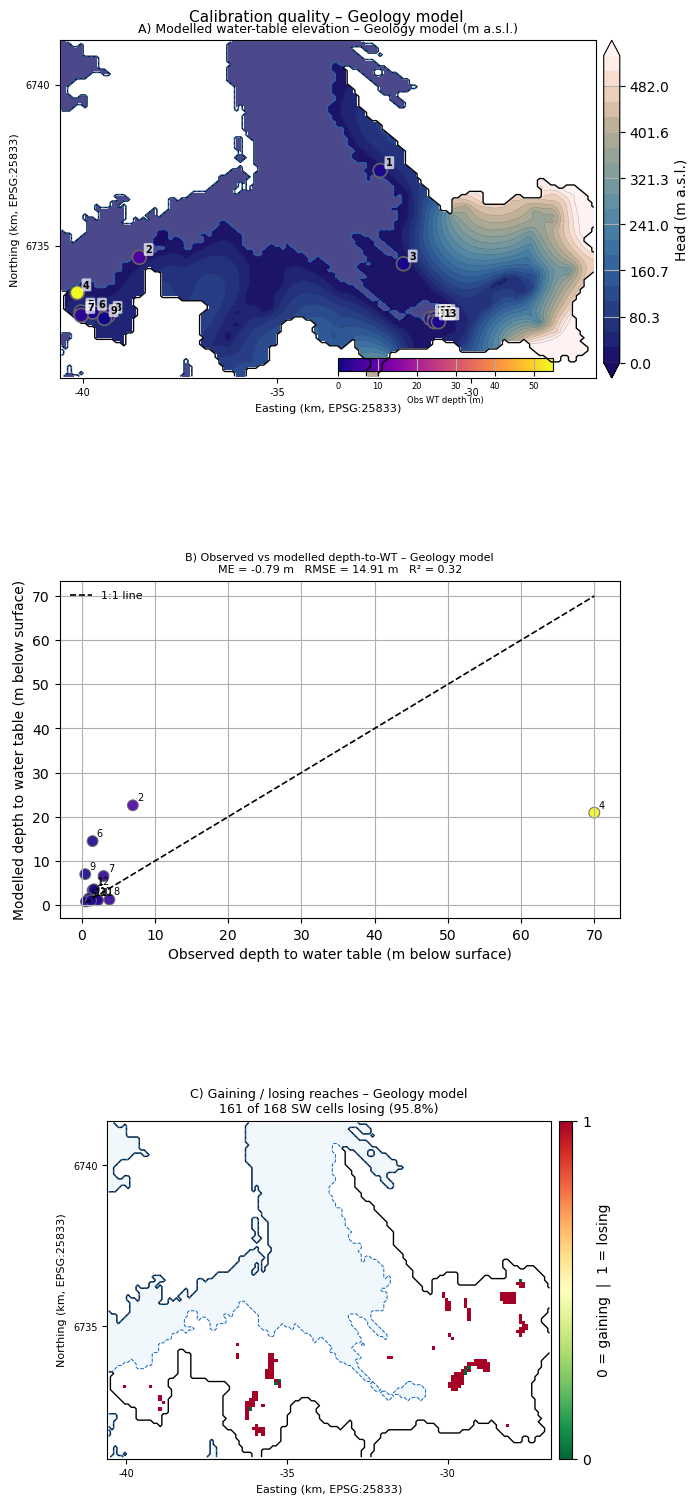


Modelled vs observed depth-to-water-table – Geology model:


,Well #,Station ID,Obs. depth-to-WT (m),Model depth-to-WT (m),Residual (m)
0,1,21330,1.50,3.35,1.85
1,2,55886,7.00,22.61,15.61
2,3,119296,1.00,1.54,0.54
4,4,10004,70.00,20.94,-49.06
6,5,141713,0.60,0.83,0.23
7,6,141715,1.50,14.51,13.01
8,7,141714,3.00,6.61,3.61
9,8,141718,3.80,1.27,-2.53
10,9,141717,0.50,7.03,6.53
11,10,129754,2.00,1.37,-0.63


In [18]:

# Calibration quality: geology model
plot_calibration_comparison(
    head_geo, diag_geo, eval_geo,
    stats_geo, targets_geo, 'Geology model'
)

# Modelled vs observed depth-to-WT table
if not eval_geo.empty:
    print('\nModelled vs observed depth-to-water-table – Geology model:')
    tbl_g = eval_geo.copy()
    tbl_g['model_depth_m'] = tbl_g['dem_m'] - tbl_g['model_head_m']
    tbl_g['depth_resid_m'] = tbl_g['model_depth_m'] - tbl_g['obs_depth_m']
    tbl_g_disp = tbl_g[['well_no', 'station_id',
                          'obs_depth_m', 'model_depth_m', 'depth_resid_m']].round(2)
    tbl_g_disp.columns = ['Well #', 'Station ID',
                            'Obs. depth-to-WT (m)', 'Model depth-to-WT (m)', 'Residual (m)']
    display(tbl_g_disp)


## Head difference map – geology minus uniform

Map the difference in modelled water-table elevation between the geology and uniform T models. Red = geology predicts higher WT.


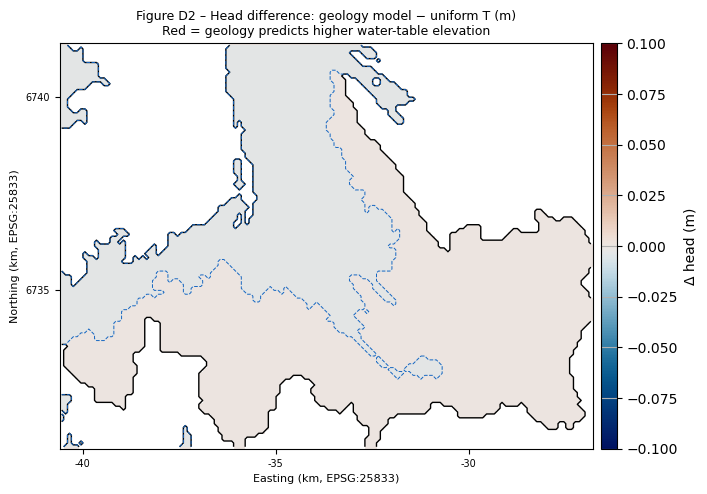

In [ ]:
# Figure D2: Head difference (geology minus uniform)
drn_elev_g = diag_geo['drn_elev']
below_wt_g = sw_cells & np.isfinite(head_geo) & (head_geo < drn_elev_g)

ph = _panel_h()
fig, ax = plt.subplots(1, 1, figsize=(7, ph))
fig.subplots_adjust(left=0.10, right=0.92, top=0.92, bottom=0.10)

diff_map = np.where(active, head_geo - head_uniform, np.nan)
vlim = max(abs(np.nanpercentile(diff_map, 2)), abs(np.nanpercentile(diff_map, 98)))
im_diff = ax.imshow(diff_map, cmap=cmc.vik, vmin=-vlim, vmax=vlim)
ax.set_title('Figure D2 – Head difference: geology model minus uniform T (m)\n'
             'Red = geology predicts higher water-table elevation')
_cbar(im_diff, ax, 'Delta head (m)')
add_map_ticks(ax)
add_map_overlays(ax)
plt.show()


## Model output maps – geology model

Six-panel spatial overview for the geology-based calibration.


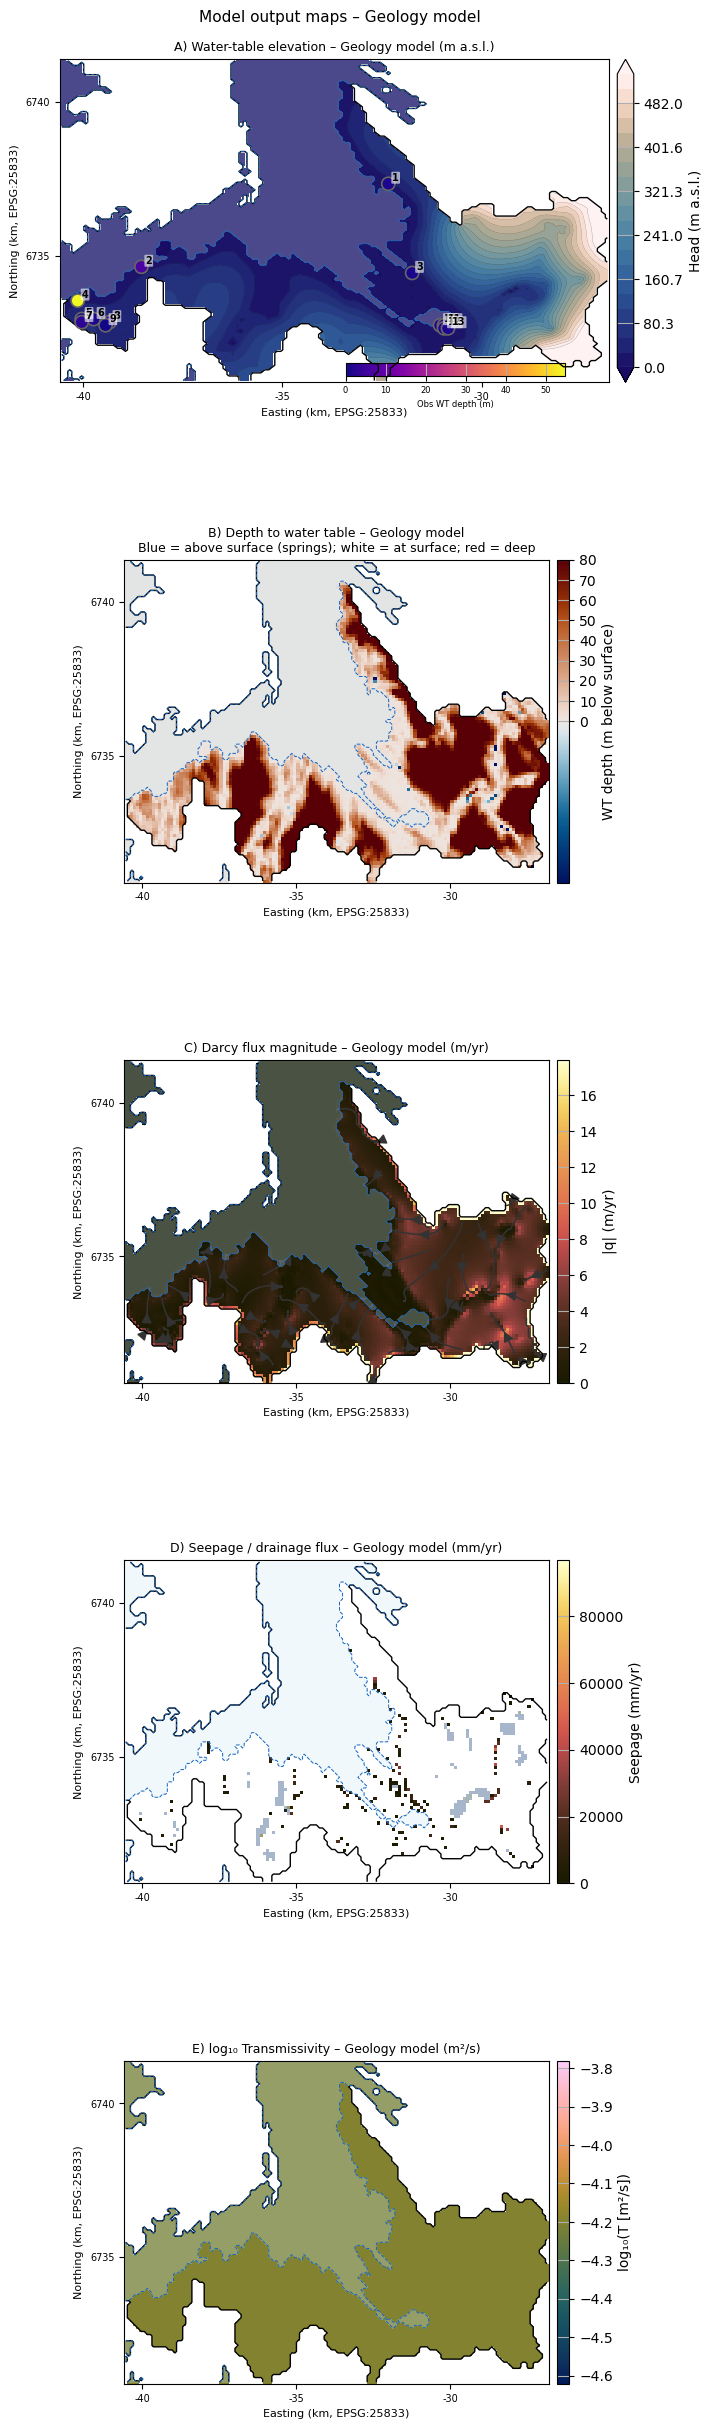

In [20]:

# Full model output maps for the geology calibration
plot_model_output(
    head_geo, diag_geo, best_hk_geo, 'Geology model',
    show_obs=eval_geo if not eval_geo.empty else None
)


## Plot cross-sections – geology model

Cross-sections along the same transects as the uniform T model, for direct side-by-side comparison.

**Compare with the uniform T sections above:**
- Does the geology model produce shallower or deeper WT in sediment-filled valleys?
- Do seepage zones expand or contract relative to the uniform T model?
- In bedrock uplands, does the lower K create a steeper WT gradient?

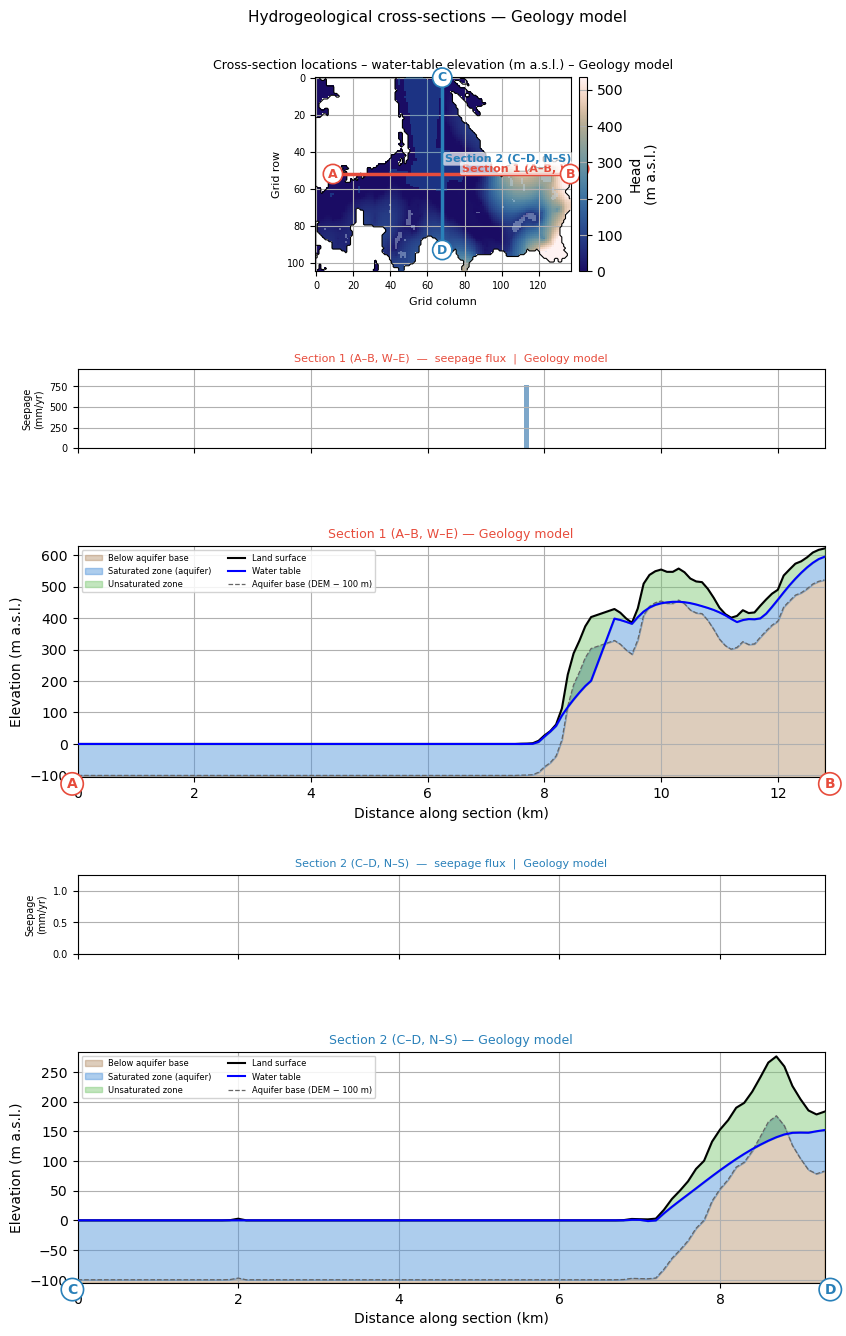

In [21]:

# Cross-sections along student-defined lines – Geology model
plot_cross_sections(head_geo, diag_geo, 'Geology model',
                    transects=user_transects if user_transects else None)



---
## Calibration Summary

Side-by-side comparison of all calibrations run so far.

**How to read the table:**
- **RMSE** is in metres. For a catchment-scale water-table model with sparse borehole data, values of 1–5 m are typical; < 2 m is good.
- **R²** measures whether spatial patterns match. R² > 0.7 is generally acceptable; negative values indicate the model is worse than simply using the mean observed head everywhere.
- **Combined loss** is the primary deciding metric — it penalises both head errors and hydrologically unrealistic behaviour (losing reaches, poor seepage patterns). Prefer the model with the lower combined loss.
- **Small differences (< ~5‥10 %)** in RMSE or R² between models are not meaningful given the uncertainty in borehole observations and the coarse model resolution.

In [22]:

def _fmt(d, key, fmt='.2f'):
    v = d.get(key, np.nan) if d else np.nan
    try:
        fv = float(v)
    except (TypeError, ValueError):
        return str(v)
    return f'{fv:{fmt}}' if np.isfinite(fv) else 'n/a'

rows = {
    'Metric': [
        'RMSE (m)', 'R²', 'Bias (m)',
        'Seepage match fraction',
        'SW stage RMSE (m)',
        'Losing-reach fraction',
        'Combined loss',
    ],
    'Uniform T': [
        _fmt(stats_uniform, 'rmse'), _fmt(stats_uniform, 'r2', '.3f'),
        _fmt(stats_uniform, 'bias'),
        _fmt(targets_uniform, 'seepage_match_fraction', '.3f'),
        _fmt(targets_uniform, 'surfacewater_stage_rmse_m'),
        _fmt(targets_uniform, 'below_wt_fraction', '.3f'),
        f"{uniform_result['loss']:.3f}",
    ],
    'Geology model': [
        _fmt(stats_geo, 'rmse'), _fmt(stats_geo, 'r2', '.3f'),
        _fmt(stats_geo, 'bias'),
        _fmt(targets_geo, 'seepage_match_fraction', '.3f'),
        _fmt(targets_geo, 'surfacewater_stage_rmse_m'),
        _fmt(targets_geo, 'below_wt_fraction', '.3f'),
        f"{geo_result['loss']:.3f}",
    ],
}

summary = pd.DataFrame(rows)
display(summary)


,Metric,Uniform T,Geology model
0,RMSE (m),14.91,14.91
1,R²,0.696,0.696
2,Bias (m),0.79,0.79
3,Seepage match fraction,0.042,0.042
4,SW stage RMSE (m),46.43,46.43
5,Losing-reach fraction,0.958,0.958
6,Combined loss,4.177,4.177



---
## Save Calibration Results for Exercise 5C

The best calibrated K field and all required grid arrays are saved to a `.npz` file and a NetCDF dataset. Exercise 5C loads these files to run flooding and pumping scenarios without repeating the calibration.

**What to do:** just run this cell. It automatically picks whichever of your two calibrations (uniform T or geology K) has the lower combined loss.

**Check:** confirm that the printed file path ends inside your `data/model_input/` directory (or your Google Drive folder on Colab) before moving to Exercise 5C.

In [ ]:
# ── Choose which calibration to save for Exercise 5C ─────────────────────────
# Options: 'uniform'  – save the uniform T model
#          'geology'  – save the geology-based model
#          'best'     – automatically pick whichever has the lower loss
save_model = 'best'

if save_model == 'uniform':
    hk_to_save = best_hk_uniform
    head_to_save = head_uniform
    diag_to_save = diag_uniform
    label_saved = 'uniform_T'
elif save_model == 'geology':
    hk_to_save = best_hk_geo
    head_to_save = head_geo
    diag_to_save = diag_geo
    label_saved = 'geology_K'
else:
    # 'best': pick the lower loss automatically
    if geo_result['loss'] < uniform_result['loss']:
        hk_to_save = best_hk_geo
        head_to_save = head_geo
        diag_to_save = diag_geo
        label_saved = 'geology_K'
    else:
        hk_to_save = best_hk_uniform
        head_to_save = head_uniform
        diag_to_save = diag_uniform
        label_saved = 'uniform_T'

print(f'Saving: {label_saved}  '
      f'(loss = {geo_result["loss"]:.3f} geology vs {uniform_result["loss"]:.3f} uniform)')

# Save legacy .npz file for Exercise 5C
cal_output = data_dir / 'calibrated_hk.npz'
np.savez(
    cal_output,
    best_hk               = hk_to_save,
    dem                   = dem,
    sw                    = sw,
    sea                   = sea,
    active                = active,
    rch                   = rch,
    delr                  = np.array([delr]),
    delc                  = np.array([delc]),
    nrow                  = np.array([nrow]),
    ncol                  = np.array([ncol]),
    aquifer_thickness_m           = np.array([aquifer_thickness_m]),
    sea_level_m                   = np.array([sea_level_m]),
    default_drain_bed_k_m_s       = np.array([default_drain_bed_k_m_s]),
    default_drain_bed_thickness_m = np.array([default_drain_bed_thickness_m]),
    drain_coupling_depth_m        = np.array([drain_coupling_depth_m]),
)
print(f'Legacy .npz saved to {cal_output}')

# Save full results as NetCDF for analysis and Exercise 5C
x_coords = np.array([transform.c + (j + 0.5) * delr for j in range(ncol)])
y_coords = np.array([transform.f - (i + 0.5) * delc for i in range(nrow)])

# Compute seepage maps for both calibrations (needed for NetCDF output)
_sw_arr_nc  = np.where(sw_cells, 1, 0)
_sea_int_nc = sea.astype(int)
seep_unif_s = gwu.seepage_flux_stats(
    diag_uniform['drn_flux'], active, _sw_arr_nc, _sea_int_nc, delr, delc)
seep_geo_s  = gwu.seepage_flux_stats(
    diag_geo['drn_flux'], active, _sw_arr_nc, _sea_int_nc, delr, delc)

ds = xr.Dataset(
    {
        'head_uniform': (
            ['y', 'x'],
            np.where(active, head_uniform, np.nan).astype(np.float32),
            {'long_name': 'Modelled water-table head - uniform T', 'units': 'm a.s.l.'}),
        'head_geology': (
            ['y', 'x'],
            np.where(active, head_geo, np.nan).astype(np.float32),
            {'long_name': 'Modelled water-table head - geology K', 'units': 'm a.s.l.'}),
        'best_hk': (
            ['y', 'x'],
            hk_to_save.astype(np.float32),
            {'long_name': 'Saved hydraulic conductivity', 'units': 'm/s'}),
        'dem': (
            ['y', 'x'],
            dem.astype(np.float32),
            {'long_name': 'Land-surface elevation', 'units': 'm a.s.l.'}),
        'active': (
            ['y', 'x'],
            active.astype(np.uint8),
            {'long_name': 'Active model domain (1 = active)'}),
        'sw': (
            ['y', 'x'],
            sw.astype(np.int16),
            {'long_name': 'Surface water type (0=none,1=lake,2=river,3=sea)'}),
        'sea': (
            ['y', 'x'],
            sea.astype(np.int16),
            {'long_name': 'Sea mask (1 = sea)'}),
        'geology': (
            ['y', 'x'],
            geo.astype(np.int16),
            {'long_name': 'Geology unit ID'}),
        'recharge_mm_yr': (
            ['y', 'x'],
            np.where(active, rch_mm_yr, np.nan).astype(np.float32),
            {'long_name': 'Effective recharge rate', 'units': 'mm/yr'}),
        'seepage_uniform_mm_yr': (
            ['y', 'x'],
            seep_unif_s['seepage_map_mm_yr'].astype(np.float32),
            {'long_name': 'Seepage flux - uniform T', 'units': 'mm/yr'}),
        'seepage_geology_mm_yr': (
            ['y', 'x'],
            seep_geo_s['seepage_map_mm_yr'].astype(np.float32),
            {'long_name': 'Seepage flux - geology K', 'units': 'mm/yr'}),
    },
    coords={
        'x': (['x'], x_coords, {'units': 'm', 'long_name': 'Easting EPSG:25833'}),
        'y': (['y'], y_coords, {'units': 'm', 'long_name': 'Northing EPSG:25833'}),
    },
    attrs={
        'title': 'Exercise 5B - calibrated steady-state groundwater model outputs',
        'crs': 'EPSG:25833',
        'cell_size_m': float(delr),
        'aquifer_thickness_m': float(aquifer_thickness_m),
        'sea_level_m': float(sea_level_m),
        'saved_calibration': label_saved,
    },
)

nc_path = data_dir / 'exercise5_model_outputs.nc'
ds.to_netcdf(nc_path)
print(f'NetCDF saved to {nc_path}')
print(ds)


Legacy .npz saved → data/model_input/calibrated_hk.npz
xarray / NetCDF saved → data/model_input/exercise5_model_outputs.nc
<xarray.Dataset> Size: 509kB
Dimensions:                (y: 105, x: 138)
Coordinates:
  * x                      (x) float64 1kB -4.054e+04 -4.044e+04 ... -2.684e+04
  * y                      (y) float64 840B 6.741e+06 6.741e+06 ... 6.731e+06
Data variables:
    head_uniform           (y, x) float32 58kB 0.0 0.0 nan nan ... nan nan nan
    head_geology           (y, x) float32 58kB 0.0 0.0 nan nan ... nan nan nan
    best_hk                (y, x) float32 58kB 6.294e-07 6.294e-07 ... 1e-12
    dem                    (y, x) float32 58kB 0.0 0.0 0.0 nan ... nan nan nan
    active                 (y, x) uint8 14kB 1 1 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    sw                     (y, x) int16 29kB 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    sea                    (y, x) int16 29kB 1 1 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    geology                (y, x) int16 29kB 0 0 0 0 0 0 0 0